# Multimodal SOC prediction with calibrated quantile intervals

Early fusion of Sentinel-2 vegetation indices (NDVI, EVI, NDRE) with SoilGrids-style covariates (pH, clay, elevation, mean annual precipitation) to predict topsoil SOC (g/kg). LightGBM quantile models give $Q_{0.05}$, $Q_{0.50}$ and $Q_{0.95}$; all scores are out-of-fold under spatial block cross-validation.

The data are semi-synthetic (`src/data_generator.py`). Numbers here describe the method's behaviour on a known generating process. They are not a claim about any real landscape.

## 1. Environment and seeds

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.neighbors import BallTree

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "src"))

from data_generator import FEATURE_COLUMNS, TARGET_COLUMN, GeneratorConfig, generate_dataset
from model import (EARTH_RADIUS_KM, QuantileGBMConfig, QuantileSOCModel, cross_validate_spatial,
                   make_spatial_folds, set_global_seed, summarise_cv)

SEED = 42
ALPHA = 0.10          # 90 % nominal interval
N_SPLITS = 5
BUFFER_KM = 5.0       # training points closer than this to any test point are dropped
set_global_seed(SEED)

DATA_PATH = ROOT / "data" / "soc_synthetic.csv"
FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print(f"root={ROOT}\nshap={shap.__version__}")

root=D:\sentinel-soil-uncertainty
shap=0.51.0


## 2. Data ingestion and feature distributions

The CSV is regenerated from the fixed seed if it is missing. `qa_cloud_residual` flags samples whose spectra carry undetected haze; it is kept for diagnostics only and is **not** a model feature, since a real pipeline cannot observe it.

1500 samples, 48 occupied blocks


,count,mean,std,min,25%,50%,75%,max
ndvi,1500.0,0.579,0.157,0.161,0.453,0.593,0.731,0.813
evi,1500.0,0.452,0.134,0.175,0.344,0.464,0.563,0.806
ndre,1500.0,0.434,0.123,0.125,0.338,0.444,0.541,0.653
ph_h2o,1500.0,6.498,0.605,4.759,6.073,6.504,6.927,8.337
clay_pct,1500.0,47.928,20.344,1.000,31.836,48.454,64.045,90.000
elevation_m,1500.0,1238.289,133.228,735.225,1156.135,1216.008,1344.643,1534.016
map_mm,1500.0,1197.841,157.928,788.264,1073.587,1205.680,1320.586,1633.728
soc_g_kg,1500.0,30.572,12.479,7.931,21.512,26.984,37.366,84.933


samples per block: min=1, median=12, max=189
                    ndvi    evi   ndre
qa_cloud_residual                     
0                  0.593  0.443  0.442
1                  0.453  0.531  0.364


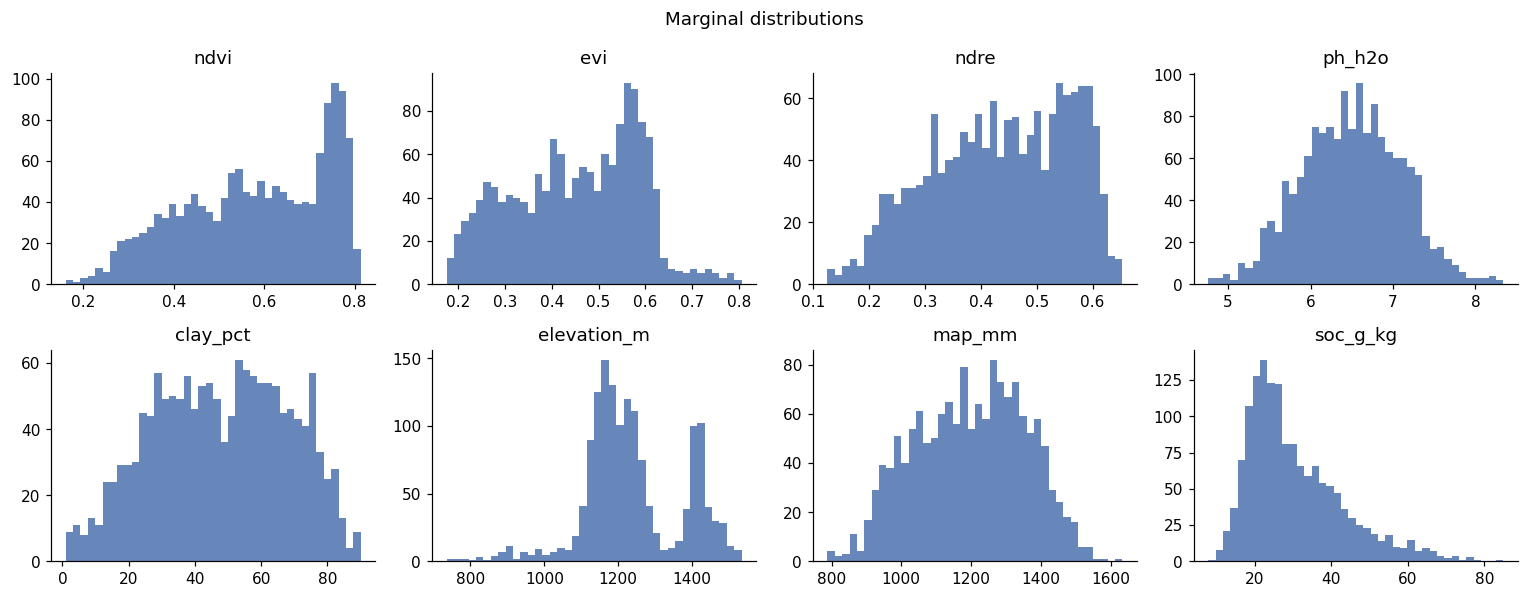

,spearman_rho_with_soc
ph_h2o,-0.50
evi,0.56
ndvi,0.61
clay_pct,0.66
ndre,0.67
map_mm,0.68
elevation_m,0.71


In [2]:
if not DATA_PATH.exists():
    DATA_PATH.parent.mkdir(exist_ok=True)
    generate_dataset(GeneratorConfig(seed=SEED)).to_csv(DATA_PATH, index=False)

df = pd.read_csv(DATA_PATH)
assert df[FEATURE_COLUMNS + [TARGET_COLUMN]].notna().all().all()
print(f"{len(df)} samples, {df['spatial_block_id'].nunique()} occupied blocks")
display(df[FEATURE_COLUMNS + [TARGET_COLUMN]].describe().T.round(3))

# Samples per block: a heavy-tailed count means fold sizes and per-fold metrics vary.
block_counts = df["spatial_block_id"].value_counts()
print("samples per block: min={}, median={:.0f}, max={}".format(
    block_counts.min(), block_counts.median(), block_counts.max()))

# Haze compresses NDVI; this is the size of the bias the model sees but cannot flag.
print(df.groupby("qa_cloud_residual")[["ndvi", "evi", "ndre"]].mean().round(3))

cols = FEATURE_COLUMNS + [TARGET_COLUMN]
fig, axes = plt.subplots(2, 4, figsize=(14, 5.5))
for ax, c in zip(axes.ravel(), cols):
    ax.hist(df[c], bins=40, color="#4C72B0", alpha=0.85)
    ax.set_title(c)
fig.suptitle("Marginal distributions")
fig.tight_layout()
fig.savefig(FIG_DIR / "feature_distributions.png", bbox_inches="tight")
plt.show()

corr = df[cols].corr(method="spearman")
display(corr[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values().round(2).to_frame("spearman_rho_with_soc"))

## 3. Spatial block cross-validation

Folds are built with `GroupKFold` on `spatial_block_id` (0.25° cells, about 28 km), so every test fold consists of whole blocks the model never saw. In addition, a 5 km buffer removes training points next to test points across block edges, where residual spatial autocorrelation would otherwise leak.

,fold,n_train,n_test,test_blocks,median_nn_dist_km,share_within_buffer
0,0,1200,300,9,7.498,0.307
1,1,1200,300,9,11.504,0.097
2,2,1201,299,10,6.216,0.391
3,3,1199,301,10,6.137,0.422
4,4,1200,300,10,7.832,0.297


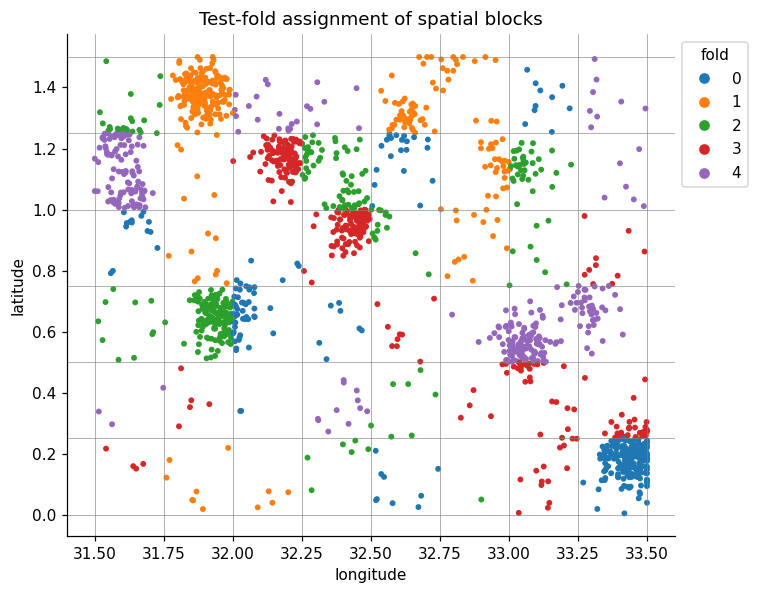

In [3]:
groups = df["spatial_block_id"].to_numpy()
folds = make_spatial_folds(groups, n_splits=N_SPLITS)

latlon_rad = np.radians(df[["latitude", "longitude"]].to_numpy())
fold_id = np.empty(len(df), dtype=int)
rows = []
for k, (tr, te) in enumerate(folds):
    fold_id[te] = k
    overlap = set(groups[tr]) & set(groups[te])
    assert not overlap, f"fold {k}: blocks in both train and test: {overlap}"
    # Nearest training point for each test point: how far the model must extrapolate.
    d, _ = BallTree(latlon_rad[tr], metric="haversine").query(latlon_rad[te], k=1)
    d_km = d[:, 0] * EARTH_RADIUS_KM
    rows.append({"fold": k, "n_train": len(tr), "n_test": len(te),
                 "test_blocks": len(set(groups[te])),
                 "median_nn_dist_km": np.median(d_km), "share_within_buffer": np.mean(d_km <= BUFFER_KM)})
display(pd.DataFrame(rows).round(3))

fig, ax = plt.subplots(figsize=(7, 5.5))
sc = ax.scatter(df["longitude"], df["latitude"], c=fold_id, cmap="tab10", vmin=0, vmax=9, s=8)
for x in np.arange(31.5, 33.51, 0.25):
    ax.axvline(x, color="grey", lw=0.4)
for y in np.arange(0.0, 1.51, 0.25):
    ax.axhline(y, color="grey", lw=0.4)
ax.set(xlabel="longitude", ylabel="latitude", title="Test-fold assignment of spatial blocks")
ax.legend(*sc.legend_elements(), title="fold", loc="upper left", bbox_to_anchor=(1, 1))
fig.tight_layout()
fig.savefig(FIG_DIR / "spatial_folds.png", bbox_inches="tight")
plt.show()

## 4. Quantile model fitting

Per fold: (a) raw quantile models on all buffered training blocks; (b) CQR models fitted on 80 % of training blocks and conformalized on the other 20 % of blocks. The median of each set is the point prediction.

In [4]:
gbm_cfg = QuantileGBMConfig(seed=SEED)
oof = cross_validate_spatial(
    df, FEATURE_COLUMNS, TARGET_COLUMN,
    folds=folds, buffer_km=BUFFER_KM, alpha=ALPHA, config=gbm_cfg,
)
display(oof.groupby("fold")[["n_train", "n_dropped_buffer", "cqr_offset_log"]].first().round(3))

crossing = ((oof["q05"] > oof["q50"]) | (oof["q50"] > oof["q95"])).sum()
print(f"quantile crossings after rearrangement: {crossing}")
# cqr_offset_log is additive on log(SOC); exp(offset) is the multiplicative widening factor.
print("mean multiplicative widening from CQR: x{:.3f}".format(np.exp(oof.groupby('fold')['cqr_offset_log'].first()).mean()))

,n_train,n_dropped_buffer,cqr_offset_log
fold,,,
0,1092,108,0.149
1,1170,30,0.146
2,1058,143,0.145
3,1063,136,0.069
4,1139,61,0.074


quantile crossings after rearrangement: 0
mean multiplicative widening from CQR: x1.124


## 5. Quantitative evaluation

Point metrics use $Q_{0.50}$. PICP is the empirical coverage of $[Q_{0.05}, Q_{0.95}]$ (target 0.90); MPIW is the mean interval width in g/kg. Coverage is also stratified by local sampling density (distance to the 10th nearest sample), because pooled coverage can hide failures in sparsely sampled areas.

In [5]:
summary = summarise_cv(oof, TARGET_COLUMN, alpha=ALPHA)
show_cols = ["variant", "fold", "n", "r2", "mae", "rmse", "picp", "mpiw", "nmpiw", "interval_score"]
display(summary[show_cols].round(3))

pooled = summary[summary["fold"] == "pooled"].set_index("variant")
for v in ("raw", "cqr"):
    r = pooled.loc[v]
    print(f"{v:>3}: R2={r.r2:.3f}  MAE={r.mae:.2f} g/kg  coverage={100*r.picp:.1f}%  MPIW={r.mpiw:.2f} g/kg")

# Local sampling density: haversine distance to the 10th nearest other sample.
d, _ = BallTree(latlon_rad, metric="haversine").query(latlon_rad, k=11)
oof["knn10_km"] = d[:, 10] * EARTH_RADIUS_KM
oof["density_class"] = pd.qcut(oof["knn10_km"], 3, labels=["dense", "medium", "sparse"])
oof["width_raw"] = oof["q95"] - oof["q05"]
oof["width_cqr"] = oof["q95_cqr"] - oof["q05_cqr"]
oof["covered_raw"] = oof[TARGET_COLUMN].between(oof["q05"], oof["q95"])
oof["covered_cqr"] = oof[TARGET_COLUMN].between(oof["q05_cqr"], oof["q95_cqr"])
oof["abs_err"] = (oof[TARGET_COLUMN] - oof["q50"]).abs()

by_density = oof.groupby("density_class", observed=True).agg(
    n=("abs_err", "size"), knn10_km=("knn10_km", "median"), mae=("abs_err", "mean"),
    picp_raw=("covered_raw", "mean"), picp_cqr=("covered_cqr", "mean"),
    mpiw_raw=("width_raw", "mean"), mpiw_cqr=("width_cqr", "mean"))
display(by_density.round(3))

by_cloud = oof.groupby("qa_cloud_residual").agg(
    n=("abs_err", "size"), mae=("abs_err", "mean"),
    picp_cqr=("covered_cqr", "mean"), mpiw_cqr=("width_cqr", "mean"))
display(by_cloud.round(3))

,variant,fold,n,r2,mae,rmse,picp,mpiw,nmpiw,interval_score
0,raw,0,300,0.572,3.567,4.579,0.720,9.867,0.175,21.584
1,raw,1,300,0.163,6.019,7.470,0.570,14.662,0.273,48.208
2,raw,2,299,0.747,4.818,6.835,0.736,13.348,0.204,32.107
3,raw,3,301,0.674,6.662,9.434,0.551,13.935,0.181,60.339
4,raw,4,300,0.504,3.820,4.915,0.743,11.642,0.248,25.184
5,raw,pooled,1500,0.696,4.978,6.882,0.664,12.691,0.165,37.503
6,cqr,0,300,0.576,3.498,4.555,0.917,17.016,0.301,19.445
7,cqr,1,300,0.130,6.193,7.616,0.903,25.647,0.478,30.645
8,cqr,2,299,0.715,5.104,7.260,0.900,19.736,0.302,25.234
9,cqr,3,301,0.661,7.028,9.628,0.698,19.385,0.252,47.170


raw: R2=0.696  MAE=4.98 g/kg  coverage=66.4%  MPIW=12.69 g/kg
cqr: R2=0.680  MAE=5.15 g/kg  coverage=86.3%  MPIW=19.81 g/kg


,n,knn10_km,mae,picp_raw,picp_cqr,mpiw_raw,mpiw_cqr
density_class,,,,,,,
dense,500,2.386,4.707,0.686,0.872,12.197,18.726
medium,500,3.756,4.971,0.666,0.890,12.959,20.365
sparse,500,9.891,5.258,0.640,0.828,12.917,20.335


,n,mae,picp_cqr,mpiw_cqr
qa_cloud_residual,,,,
0,1345,4.853,0.868,19.707
1,155,6.068,0.819,20.694


## 6. Diagnostics

(a) Out-of-fold median against observed SOC with the CQR 90 % interval. (b) Interval width at each sample location. (c) Coverage by sampling-density class. (d) SHAP attribution for a median model refitted on all data. SHAP values are on the log(SOC) scale that the model is trained on.

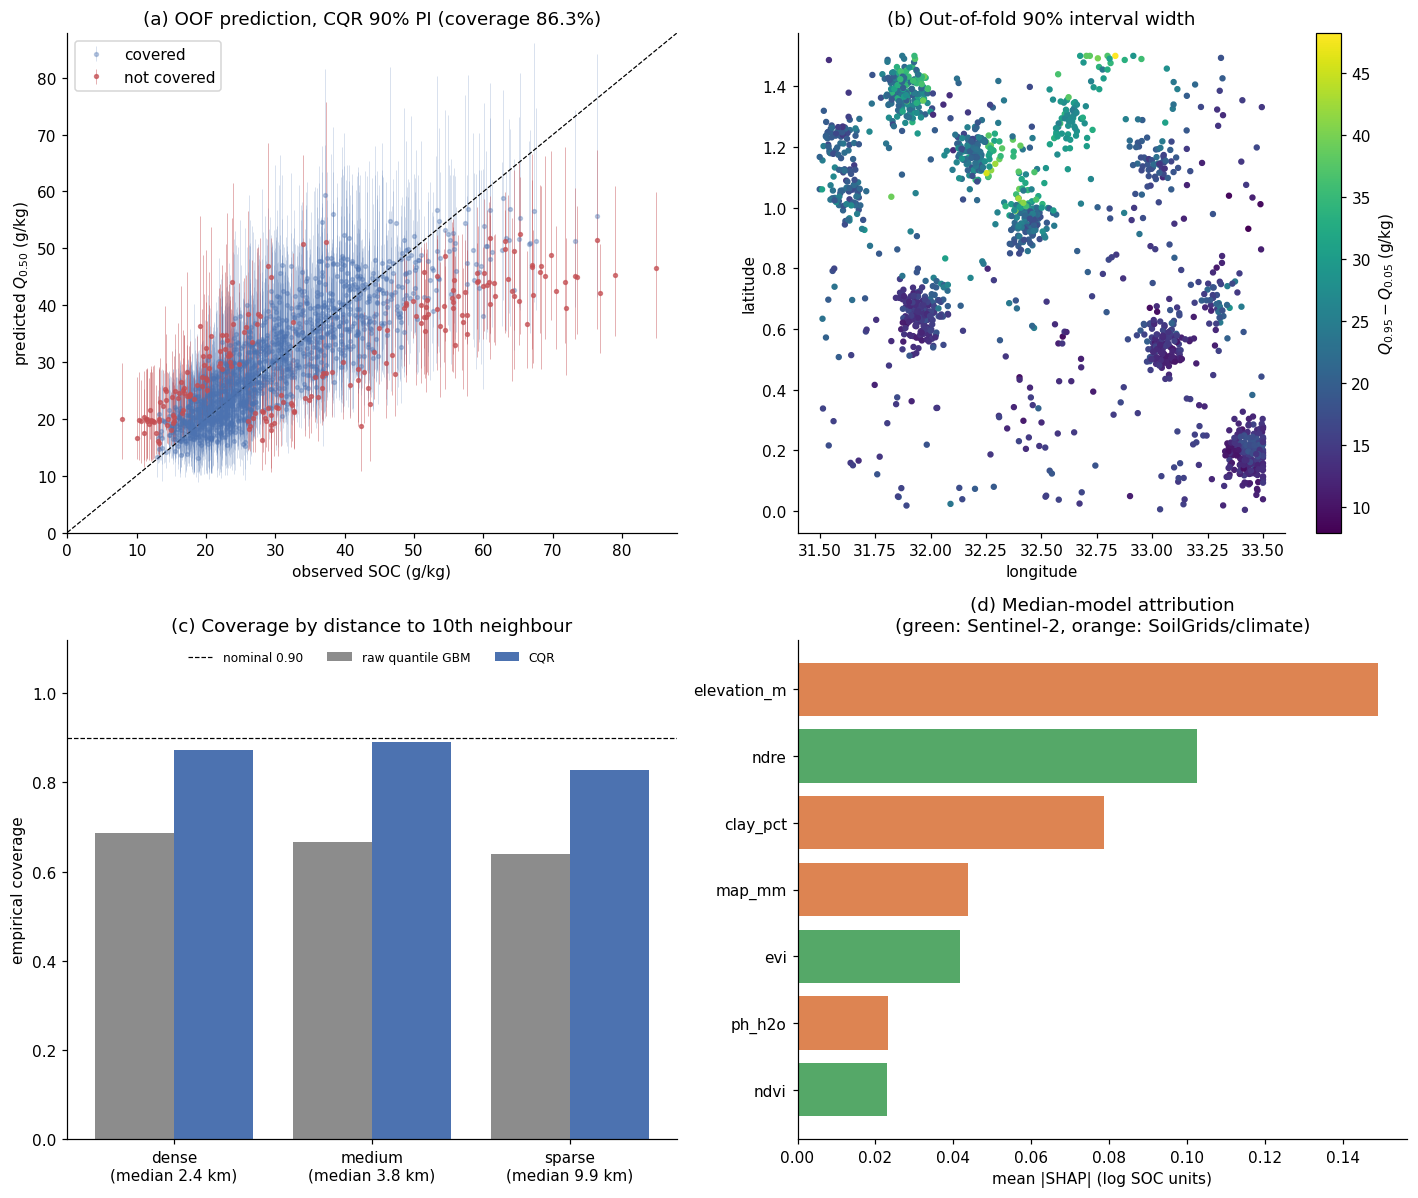

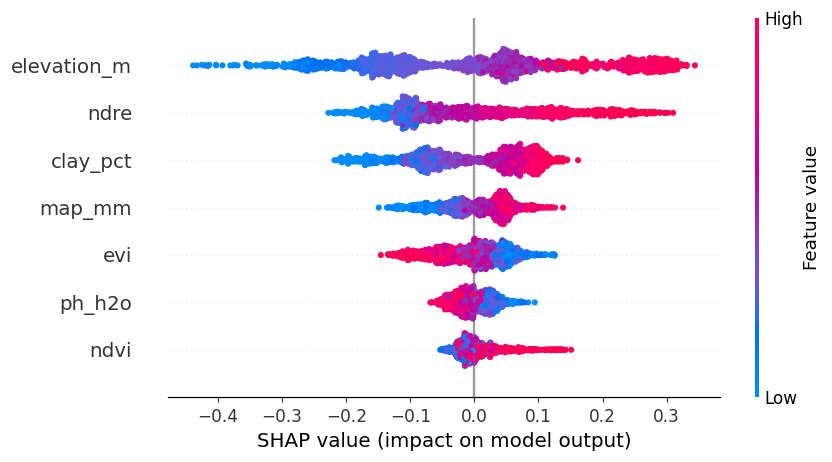

share of mean |SHAP| from Sentinel-2 indices: 0.36
Spearman(interval width, knn10 distance): 0.06


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))

# (a) predicted vs observed
ax = axes[0, 0]
y, lo, med, hi = (oof[c].to_numpy() for c in (TARGET_COLUMN, "q05_cqr", "q50_cqr", "q95_cqr"))
miss = ~oof["covered_cqr"].to_numpy()
ax.errorbar(y[~miss], med[~miss], yerr=[med[~miss] - lo[~miss], hi[~miss] - med[~miss]],
            fmt="o", ms=2.5, lw=0.4, alpha=0.35, color="#4C72B0", label="covered")
ax.errorbar(y[miss], med[miss], yerr=[med[miss] - lo[miss], hi[miss] - med[miss]],
            fmt="o", ms=2.5, lw=0.4, alpha=0.7, color="#C44E52", label="not covered")
lim = [0, max(y.max(), hi.max()) * 1.02]
ax.plot(lim, lim, "k--", lw=0.8)
ax.set(xlim=lim, ylim=lim, xlabel="observed SOC (g/kg)", ylabel="predicted $Q_{0.50}$ (g/kg)",
       title=f"(a) OOF prediction, CQR 90% PI (coverage {100 * (~miss).mean():.1f}%)")
ax.legend(loc="upper left")

# (b) spatial map of interval width
ax = axes[0, 1]
sc = ax.scatter(oof["longitude"], oof["latitude"], c=oof["width_cqr"], cmap="viridis", s=10)
fig.colorbar(sc, ax=ax, label="$Q_{0.95} - Q_{0.05}$ (g/kg)")
ax.set(xlabel="longitude", ylabel="latitude", title="(b) Out-of-fold 90% interval width")

# (c) coverage by density class
ax = axes[1, 0]
xpos = np.arange(len(by_density))
ax.bar(xpos - 0.2, by_density["picp_raw"], 0.4, label="raw quantile GBM", color="#8C8C8C")
ax.bar(xpos + 0.2, by_density["picp_cqr"], 0.4, label="CQR", color="#4C72B0")
ax.axhline(1 - ALPHA, color="k", ls="--", lw=0.8, label="nominal 0.90")
ax.set_xticks(xpos, [f"{c}\n(median {d:.1f} km)" for c, d in zip(by_density.index, by_density["knn10_km"])])
ax.set(ylim=(0, 1.12), ylabel="empirical coverage", title="(c) Coverage by distance to 10th neighbour")
ax.legend(loc="upper center", ncol=3, fontsize=8, frameon=False)

# (d) SHAP on a median model trained on all samples
final_median = QuantileSOCModel(quantiles=(0.5,), config=gbm_cfg).fit(df[FEATURE_COLUMNS], df[TARGET_COLUMN])
explainer = shap.TreeExplainer(final_median.models[0.5])
shap_values = explainer.shap_values(df[FEATURE_COLUMNS])
mean_abs = pd.Series(np.abs(shap_values).mean(axis=0), index=FEATURE_COLUMNS).sort_values()
ax = axes[1, 1]
colors = ["#55A868" if f in ("ndvi", "evi", "ndre") else "#DD8452" for f in mean_abs.index]
ax.barh(mean_abs.index, mean_abs.values, color=colors)
ax.set(xlabel="mean |SHAP| (log SOC units)", title="(d) Median-model attribution\n(green: Sentinel-2, orange: SoilGrids/climate)")

fig.tight_layout()
fig.savefig(FIG_DIR / "diagnostics.png", bbox_inches="tight")
plt.show()

# shap's beeswarm jitter calls np.random.seed internally; the resulting FutureWarning is noise.
with warnings.catch_warnings():
    warnings.simplefilter("ignore", FutureWarning)
    shap.summary_plot(shap_values, df[FEATURE_COLUMNS], show=False)
plt.gcf().savefig(FIG_DIR / "shap_beeswarm.png", bbox_inches="tight")
plt.show()

spectral_share = mean_abs[["ndvi", "evi", "ndre"]].sum() / mean_abs.sum()
print(f"share of mean |SHAP| from Sentinel-2 indices: {spectral_share:.2f}")
print("Spearman(interval width, knn10 distance): {:.2f}".format(
    oof[["width_cqr", "knn10_km"]].corr(method="spearman").iloc[0, 1]))